<a href="https://colab.research.google.com/github/LeonimerMelo/Reinforcement-Learning/blob/Q-Learning/Rob%C3%B3tica_MDP_Q_Learning_(RL)_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Processos de Decisão de Markov (MDP)
Processos de Decisão de Markov (MDP) para resolver um problema de aprendizado por reforço em Python.

Este código implementa um algoritmo de Valor-Iteração para resolver um problema de aprendizado por reforço usando Processos de Decisão de Markov (MDPs). Vou explicar os principais conceitos e partes do código:

### Conceitos Básicos do Código

1. **Processo de Decisão de Markov (MDP)**: Um framework matemático para modelar tomada de decisões em ambientes onde os resultados são parcialmente aleatórios e parcialmente controlados por um agente.

2. **Algoritmo de Valor-Iteração**: Um método para encontrar a política ótima calculando iterativamente os valores esperados de cada estado.

### Explicação do Ambiente

O código implementa um "GridWorld" (mundo em grade) 4x4 onde:
- O agente começa na posição (0,0)
- Existe um estado objetivo na posição (3,3) com recompensa +1
- Existe um estado com penalidade na posição (1,1) com recompensa -1
- Cada movimento tem uma pequena penalidade (-0.04) para incentivar o agente a encontrar o caminho mais curto

### Componentes do Código

1. **Classe `GridWorldMDP`**: Representa o ambiente e implementa o algoritmo
   - **Inicialização**: Define estados, ações, recompensas e parâmetros do MDP
   - **Funções de transição**: Calculam o próximo estado e recompensa

2. **Algoritmo de Valor-Iteração**:
   - Itera repetidamente sobre todos os estados
   - Para cada estado, calcula o valor esperado de cada ação possível
   - Atualiza o valor do estado para o máximo valor esperado
   - Repete até convergência (quando os valores param de mudar significativamente)

3. **Extração da Política**:
   - Depois que os valores convergirem, determina a melhor ação para cada estado
   - A política ótima diz ao agente qual direção seguir em cada posição

4. **Visualização**:
   - Funções para mostrar os valores de cada estado como um mapa de calor
   - Visualização da política ótima usando setas direcionais

### Como Funciona o Aprendizado

1. O algoritmo começa com valores arbitrários para cada estado (zeros)
2. A cada iteração, atualiza os valores com base nas recompensas imediatas e valores futuros esperados
3. Eventualmente, os valores convergem para os valores ótimos
4. A partir desses valores, extraímos a política ótima (melhor ação em cada estado)

### Para Executar o Código

O código inclui um exemplo completo que:
1. Cria um ambiente GridWorld
2. Executa o algoritmo de valor-iteração
3. Visualiza os valores finais e a política ótima
4. Imprime os valores e ações para cada estado

Este exemplo é didático e mostra os princípios fundamentais de MDPs e aprendizado por reforço de forma clara e visual. O agente aprende a navegar até o objetivo enquanto evita o estado de penalidade.

In [61]:
import numpy as np
import matplotlib.pyplot as plt

class GridWorldMDP:
    """
    Uma implementação simples de um mundo em grade 4x4 como um Processo de Decisão de Markov.
    O agente deve aprender a chegar ao estado objetivo (3,3) evitando um estado com penalidade (1,1).
    """
    def __init__(self):
        # Definindo os parâmetros do ambiente
        self.altura = 4
        self.largura = 4
        self.estados = [(i, j) for i in range(self.altura) for j in range(self.largura)]
        self.acoes = ["cima", "direita", "baixo", "esquerda"]

        # Estado inicial e estados especiais
        self.estado_inicial = (0, 0)
        self.estado_objetivo = (3, 3)  # Estado terminal com recompensa +1
        self.estado_buraco = (1, 1)    # Estado terminal com recompensa -1

        # Parâmetros do MDP
        self.gamma = 0.9  # Fator de desconto

        # Inicialização da política e valores
        self.valores = {estado: 0 for estado in self.estados}
        self.politica = {estado: np.random.choice(self.acoes) for estado in self.estados}

    def obter_proxima_posicao(self, estado, acao):
        """Retorna o próximo estado após executar uma ação."""
        i, j = estado

        if acao == "cima":
            novo_i = max(0, i - 1)
            novo_j = j
        elif acao == "direita":
            novo_i = i
            novo_j = min(self.largura - 1, j + 1)
        elif acao == "baixo":
            novo_i = min(self.altura - 1, i + 1)
            novo_j = j
        elif acao == "esquerda":
            novo_i = i
            novo_j = max(0, j - 1)

        return (novo_i, novo_j)

    def obter_recompensa(self, estado, acao, proximo_estado):
        """Retorna a recompensa associada à transição."""
        if proximo_estado == self.estado_objetivo:
            return 1.0
        elif proximo_estado == self.estado_buraco:
            return -1.0
        else:
            return -0.04  # Pequena penalidade para encorajar a rapidez

    def e_terminal(self, estado):
        """Verifica se um estado é terminal."""
        return estado == self.estado_objetivo or estado == self.estado_buraco

    def algoritmo_valor_iteracao(self, num_iteracoes=100, epsilon=1e-6):
        """Implementa o algoritmo de valor-iteração para encontrar a política ótima."""
        historico_valores = []

        # Inicialização da política e valores
        self.valores = {estado: 0 for estado in self.estados}
        self.politica = {estado: np.random.choice(self.acoes) for estado in self.estados}

        for _ in range(num_iteracoes):
            delta = 0
            novos_valores = self.valores.copy()

            # Iteração para atualizar os valores de cada estado
            for estado in self.estados:
                # Verifica se um estado é terminal
                if self.e_terminal(estado):
                    continue

                # Calculando os valores-Q para cada ação possível
                valores_q = []
                for acao in self.acoes:
                    proximo_estado = self.obter_proxima_posicao(estado, acao)
                    recompensa = self.obter_recompensa(estado, acao, proximo_estado)

                    valor_proximo = self.valores[proximo_estado]
                    valores_q.append(recompensa + self.gamma * valor_proximo)

                # Atualização do valor do estado
                melhor_valor = max(valores_q)
                novos_valores[estado] = melhor_valor

                # Calculando a diferença máxima para verificar convergência
                delta = max(delta, abs(novos_valores[estado] - self.valores[estado]))

            # Atualizando os valores
            self.valores = novos_valores

            # Guardando o histórico para visualização
            historico_valores.append(self.valores.copy())

            # Critério de parada por convergência
            if delta < epsilon:
                print(f"Convergiu após {_+1} iterações")
                break

        # Extração da política ótima
        for estado in self.estados:
            # Verifica se um estado é terminal
            if self.e_terminal(estado):
                continue

            melhores_acoes = []
            melhor_valor = float('-inf')

            for acao in self.acoes:
                proximo_estado = self.obter_proxima_posicao(estado, acao)
                recompensa = self.obter_recompensa(estado, acao, proximo_estado)
                valor_q = recompensa + self.gamma * self.valores[proximo_estado]

                if valor_q > melhor_valor:
                    melhores_acoes = [acao]
                    melhor_valor = valor_q
                elif valor_q == melhor_valor:
                    melhores_acoes.append(acao)

            # Seleciona aleatoriamente entre as melhores ações
            self.politica[estado] = np.random.choice(melhores_acoes)

        return historico_valores

    def visualizar_valores(self):
        """Visualiza a matriz de valores dos estados."""
        matriz_valores = np.zeros((self.altura, self.largura))
        for i in range(self.altura):
            for j in range(self.largura):
                matriz_valores[i, j] = self.valores[(i, j)]

        plt.figure(figsize=(8, 6))
        plt.imshow(matriz_valores, cmap='viridis')
        plt.colorbar(label='Valor do Estado')
        plt.title('Mapa de Valores do Estado')

        # Marcando estados especiais
        plt.plot(self.estado_objetivo[1], self.estado_objetivo[0], 'g*', markersize=15)
        plt.plot(self.estado_buraco[1], self.estado_buraco[0], 'rx', markersize=15)

        for i in range(self.altura):
            for j in range(self.largura):
                plt.text(j, i, f"{matriz_valores[i, j]:.2f}",
                        ha="center", va="center", color="white")

        plt.tight_layout()
        plt.show()

    def visualizar_politica(self):
        """Visualiza a política ótima."""
        matriz_politica = np.zeros((self.altura, self.largura), dtype=object)

        # Símbolos para as direções
        simbolos = {
            "cima": "↑",
            "direita": "→",
            "baixo": "↓",
            "esquerda": "←"
        }

        for i in range(self.altura):
            for j in range(self.largura):
                estado = (i, j)
                if estado == self.estado_objetivo:
                    matriz_politica[i, j] = "G"  # Goal
                elif estado == self.estado_buraco:
                    matriz_politica[i, j] = "X"  # Buraco
                else:
                    matriz_politica[i, j] = simbolos[self.politica[estado]]

        plt.figure(figsize=(8, 6))
        ax = plt.gca()

        # Criando a grade
        for i in range(self.altura + 1):
            plt.axhline(i - 0.5, color='black', linestyle='-', linewidth=1)
        for j in range(self.largura + 1):
            plt.axvline(j - 0.5, color='black', linestyle='-', linewidth=1)

        # Preenchendo com as ações
        for i in range(self.altura):
            for j in range(self.largura):
                ax.text(j, i, matriz_politica[i, j], ha='center', va='center', fontsize=20)

        # Configurações visuais
        plt.title('Política Ótima')
        plt.xlim(-0.5, self.largura - 0.5)
        plt.ylim(self.altura - 0.5, -0.5)
        plt.xticks(range(self.largura))
        plt.yticks(range(self.altura))
        plt.grid(False)
        plt.tight_layout()
        plt.show()

In [62]:
# Criação do ambiente MDP
mdp = GridWorldMDP()

In [82]:
# Executando o exemplo
# Resolvendo o MDP usando o algoritmo de valor-iteração
historico = mdp.algoritmo_valor_iteracao(num_iteracoes=100)

Convergiu após 7 iterações


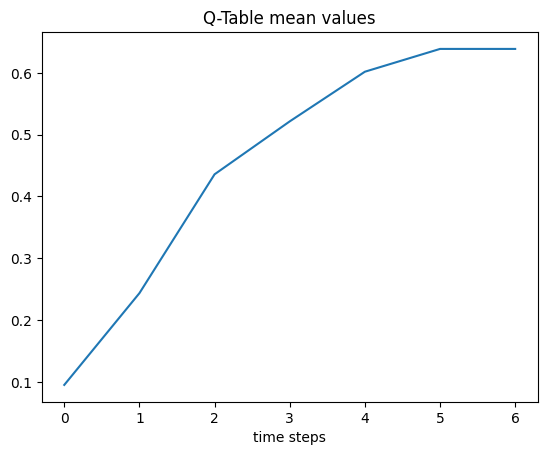

In [83]:
c=[]
for i in range(len(historico)):
  a = np.array(list(historico[i].values()))
  b = np.mean(a)
  c.append(b)

plt.plot(c)
plt.title('Q-Table mean values')
plt.xlabel('time steps')
plt.show()

In [84]:
# Mostrando como evoluíram os valores ao longo das iterações
print("\nValores finais para cada estado:")
for estado, valor in mdp.valores.items():
    print(f"Estado {estado}: {valor:.4f}")


Valores finais para cada estado:
Estado (0, 0): 0.4267
Estado (0, 1): 0.5185
Estado (0, 2): 0.6206
Estado (0, 3): 0.7340
Estado (1, 0): 0.5185
Estado (1, 1): 0.0000
Estado (1, 2): 0.7340
Estado (1, 3): 0.8600
Estado (2, 0): 0.6206
Estado (2, 1): 0.7340
Estado (2, 2): 0.8600
Estado (2, 3): 1.0000
Estado (3, 0): 0.7340
Estado (3, 1): 0.8600
Estado (3, 2): 1.0000
Estado (3, 3): 0.0000


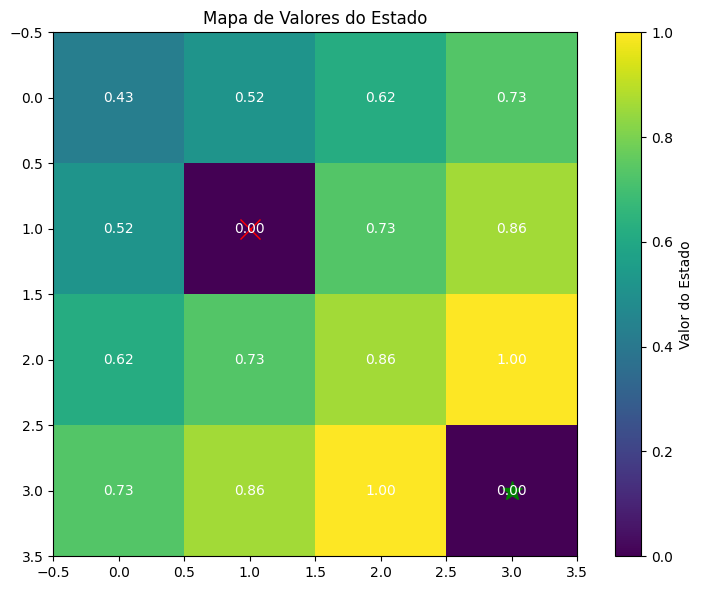

In [85]:
# Visualizando os resultados
mdp.visualizar_valores()

In [86]:
print("\nPolítica ótima:")
for estado, acao in mdp.politica.items():
    if not mdp.e_terminal(estado):
        print(f"No estado {estado}: mover para {acao}")


Política ótima:
No estado (0, 0): mover para baixo
No estado (0, 1): mover para direita
No estado (0, 2): mover para direita
No estado (0, 3): mover para baixo
No estado (1, 0): mover para baixo
No estado (1, 2): mover para direita
No estado (1, 3): mover para baixo
No estado (2, 0): mover para direita
No estado (2, 1): mover para baixo
No estado (2, 2): mover para direita
No estado (2, 3): mover para baixo
No estado (3, 0): mover para direita
No estado (3, 1): mover para direita
No estado (3, 2): mover para direita


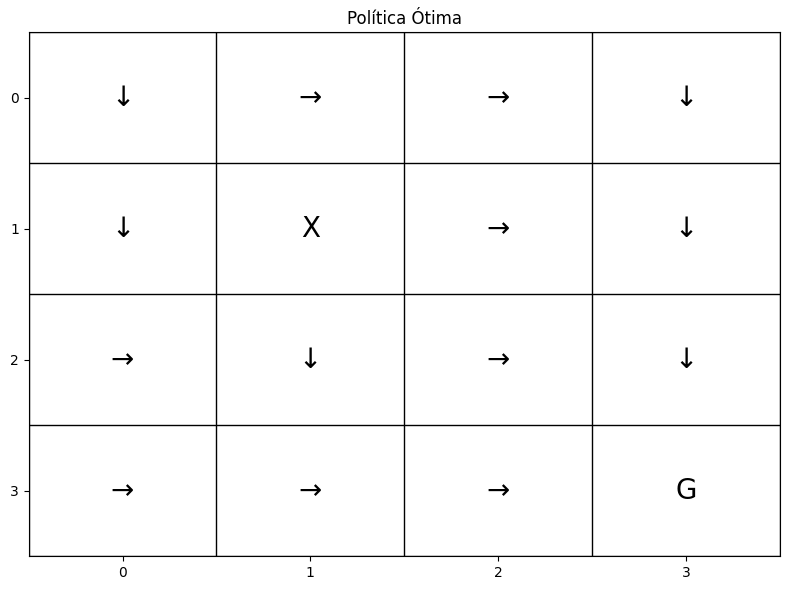

In [87]:
mdp.visualizar_politica()

##Exercícios
1. Modificar o grid para 5 x 5 com dois obstáculos (escolha a posição)
1. Teste e compare os resultados e os tempos de convergência
1. Modificar o grid para 8 x 8 com quatro obstáculos
1. Teste e compare os resultados e os tempos de convergência
1. Modificar o grid para 10 x 10 com oito obstáculos
1. Teste e compare os resultados e os tempos de convergência
1. Armazenar o valor média da tabela Q para cada iteração e depois plotar. Fazer isso para cada um dos casos acima